# $\color{lightgreen}{\text{THE FRAUD DETECTION PLAYBOOK — APPLIED EVERYWHERE}}$




$\color{green}{\text{Instructions for Participants:}}$

1. Click 'File' -> 'Save a copy in Drive' to create your own editable version.
2. Complete the TODO blocks marked with 'None' or '___'.

$\color{lightgreen}{\text{STEP 1: Run this cell to install required libraries and packages}}$




In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
print("Environment setup complete! Ready to load data.")

Environment setup complete! Ready to load data.


$\color{lightgreen}{\text{Step 2: Load DataSet}}$


In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

df = pd.read_csv(url)

print("Loaded dataset: Credit Card Fraud")
print("Dataset Shape:", df.shape)
display(df.head())

Loaded dataset: Credit Card Fraud
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


$\color{lightgreen}{\text{Step 3: Feature Selection and Scaling}}$


In [5]:
from sklearn.preprocessing import StandardScaler

# Select the features
feature_cols = ['Amount', 'V1', 'V2', 'V3']
X = df[feature_cols]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Feature Array Shape:", X_scaled.shape)

Scaled Feature Array Shape: (284807, 4)


$\color{lightgreen}{\text{Step 4: Statistical Outlier Datection using z-score}}$


In [6]:
from scipy import stats
import numpy as np

def detect_zscore_anomalies(data_column, threshold=3.0):
    """Returns 1 for anomalies and 0 for normal values."""
    z_scores = np.abs(stats.zscore(data_column))
    return np.where(z_scores > threshold, 1, 0)

# Apply Z-score detection to the Amount column
target_col = 'Amount'

df['zscore_anomaly'] = detect_zscore_anomalies(
    df[target_col],
    threshold=3.0
)

print(f"Z-Score Anomalies Detected: {df['zscore_anomaly'].sum()}")

Z-Score Anomalies Detected: 4076


$\color{lightgreen}{\text{Step 5: Density based methods}}$


In [7]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

lof_preds = lof.fit_predict(X_scaled)

df['lof_anomaly'] = np.where(lof_preds == -1, 1, 0)

print(f"LOF Anomalies Detected: {df['lof_anomaly'].sum()}")

LOF Anomalies Detected: 5697


/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


 $\color{lightgreen}{\text{Step 6: Tree based methods}}$


In [8]:
from sklearn.ensemble import IsolationForest
import numpy as np

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

iso_preds = iso_forest.fit_predict(X_scaled)

df['iso_anomaly'] = np.where(
    iso_preds == -1, 1, 0
)

print(
    f"Isolation Forest Anomalies Detected: "
    f"{df['iso_anomaly'].sum()}"
)

Isolation Forest Anomalies Detected: 5697


$\color{lightgreen}{\text{Step 7: Visualization and Evaluation}}$


Plotting fearures against Isolation Forest anomaly flags

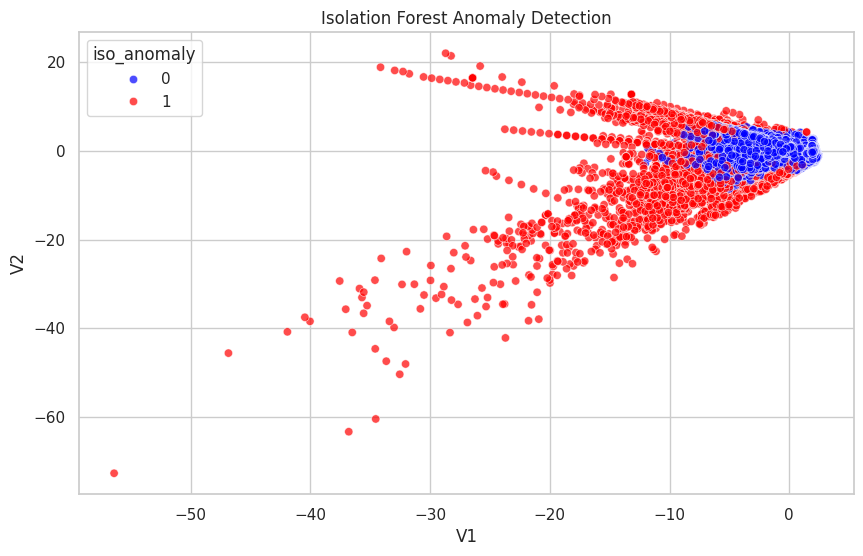

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='V1',
    y='V2',
    hue='iso_anomaly',
    palette={0: 'blue', 1: 'red'},
    alpha=0.7
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("V1")
plt.ylabel("V2")
plt.show()

$\color{lightgreen}{\text{Step 8: Custom threshold tuning (Advanced Task)}}$




1.   Extract raw anomaly scores using score_samples()
2.   Note: Lower/negative scores indicate higher probability of being an anomaly



In [10]:
# Get anomaly scores from Isolation Forest
raw_scores = iso_forest.score_samples(X_scaled)

df['raw_score'] = raw_scores

# Select the lowest 1% of scores
threshold_cutoff = df['raw_score'].quantile(0.01)

# Flag transactions below the cutoff
df['custom_flag'] = np.where(
    df['raw_score'] < threshold_cutoff,
    1,
    0
)

print(f"Custom Threshold Score: {threshold_cutoff:.4f}")
print(f"Custom Flagged Anomalies: {df['custom_flag'].sum()}")

Custom Threshold Score: -0.7043
Custom Flagged Anomalies: 2849


In [12]:
print("Dataset:", df.shape)
print("Z-score anomalies:", df['zscore_anomaly'].sum())
print("LOF anomalies:", df['lof_anomaly'].sum())
print("Isolation Forest anomalies:", df['iso_anomaly'].sum())
print("Custom threshold anomalies:", df['custom_flag'].sum())

print("\nblah blah blah completed")

Dataset: (284807, 36)
Z-score anomalies: 4076
LOF anomalies: 5697
Isolation Forest anomalies: 5697
Custom threshold anomalies: 2849

blah blah blah completed
